In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

%matplotlib inline

In [5]:
df = pd.read_csv("data/diabetes_uncleaned.csv")
print(df.shape)
df.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


No empty rows, all int64 type except BMI, DiabetesPedigreeFunction

No duplicated rows

In [29]:
zero_invalid = ["Glucose", "BloodPressure", "Insulin", "SkinThickness", "BMI"]
for col in zero_invalid:
    count = (df[col]==0).sum()
    pct = count/len(df) * 100
    print(f"{col} : {count}, ({pct}%)")

Glucose : 5, (0.6510416666666667%)
BloodPressure : 35, (4.557291666666666%)
Insulin : 374, (48.69791666666667%)
SkinThickness : 227, (29.557291666666668%)
BMI : 11, (1.4322916666666665%)


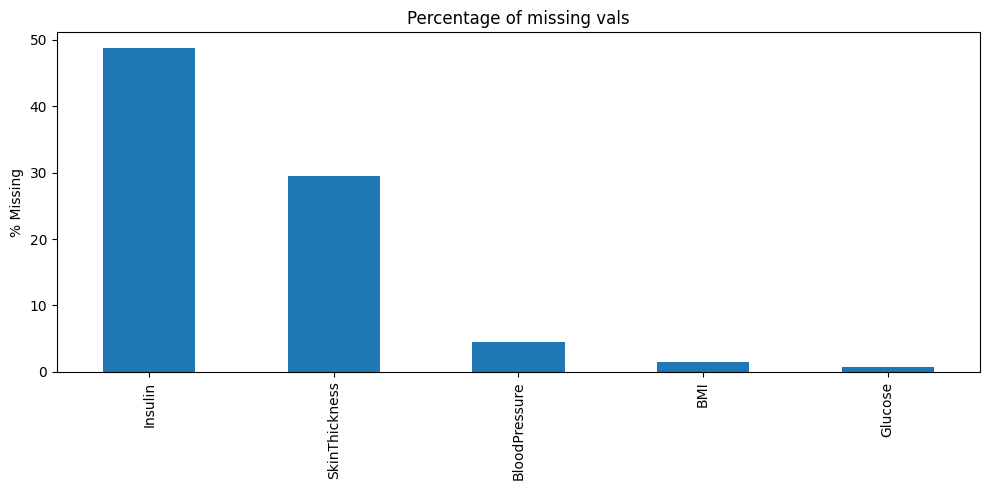

In [30]:
df_missing = df.copy()
for col in zero_invalid:
    df_missing[col] = df_missing[col].replace(0,np.nan)

fig, ax = plt.subplots(figsize = (10,5))
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind = "bar", ax=ax)
ax.set_title("Percentage of missing vals")
ax.set_ylabel("% Missing")
plt.tight_layout()
plt.show()

Feature Distribution work:

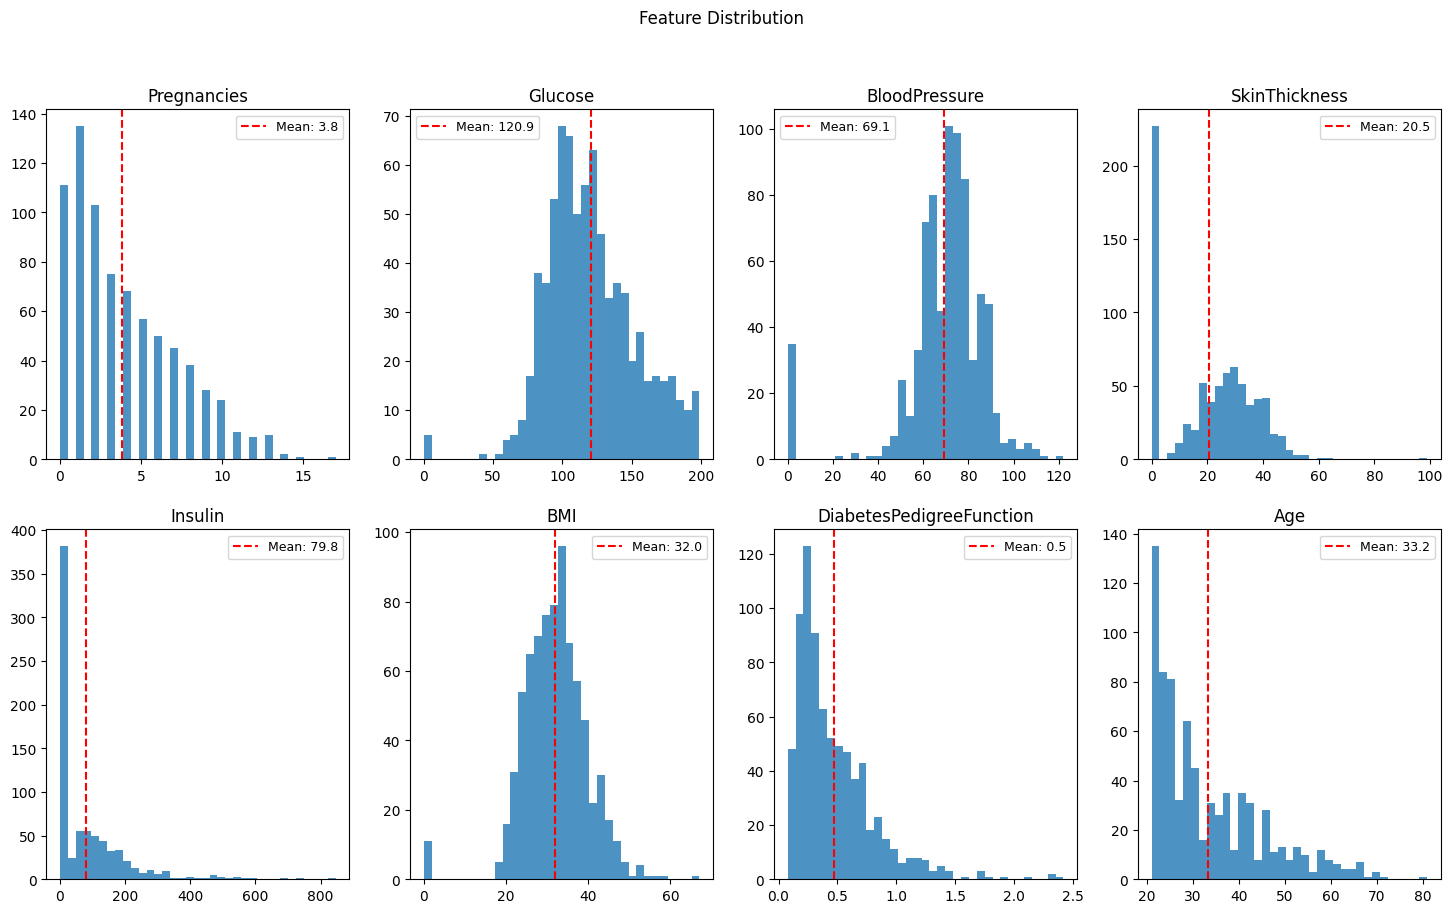

In [34]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig,ax = plt.subplots(2,4, figsize=(18,10))
ax = ax.flatten()

for i, col in enumerate(features):
    ax[i].hist(df[col], bins = 35, alpha = 0.8)
    ax[i].set_title(col)
    ax[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.1f}")
    ax[i].legend(fontsize=9)
    
plt.suptitle("Feature Distribution")
plt.show()

Spot Outliers:

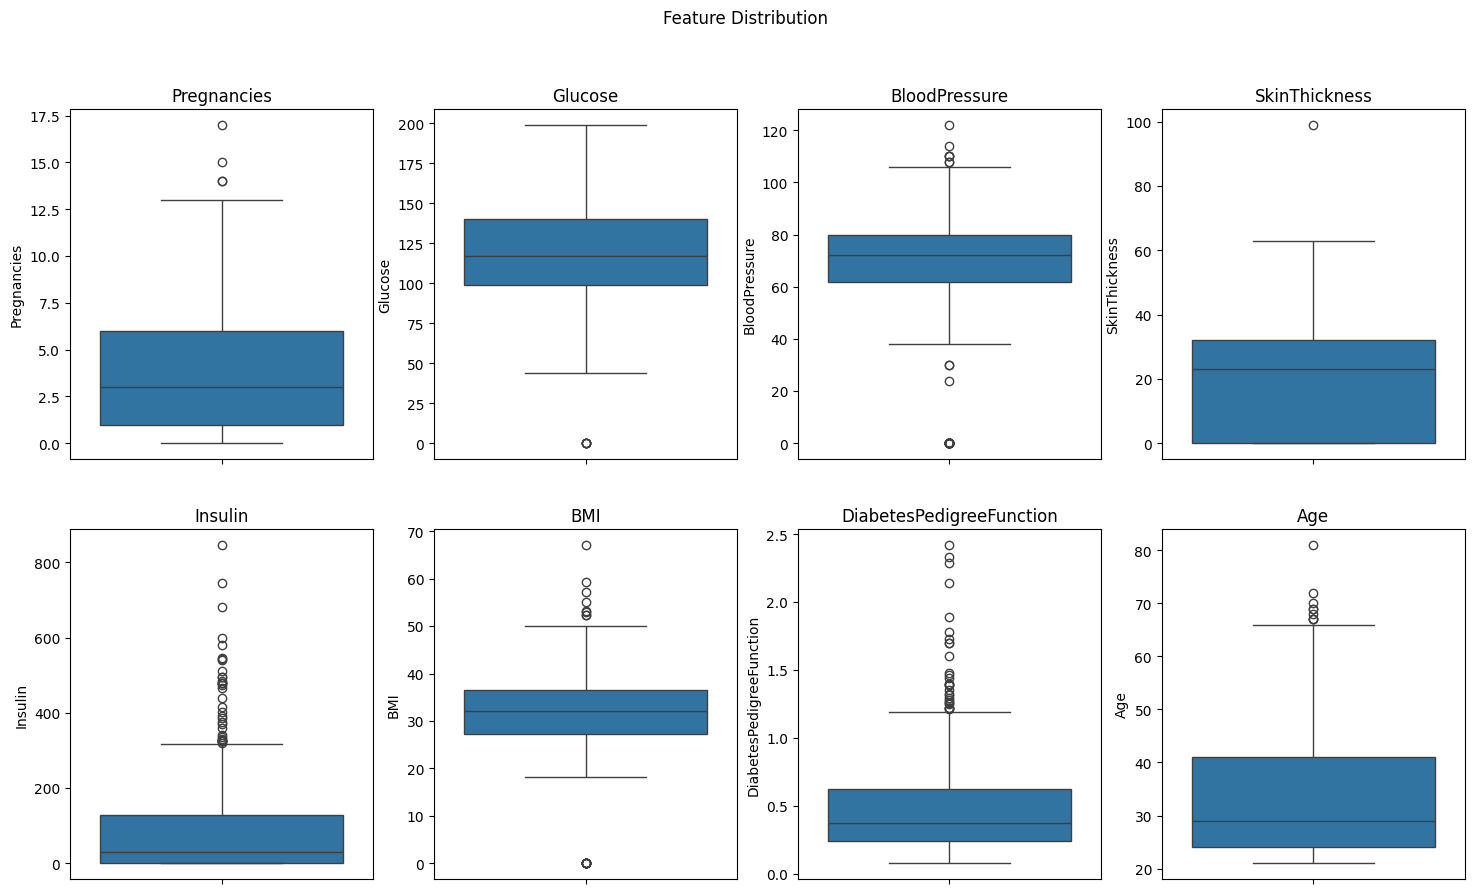

In [36]:
fig,ax = plt.subplots(2,4, figsize=(18,10))
ax =ax.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax = ax[i])
    ax[i].set_title(col)

plt.suptitle("Feature Distribution")
plt.show()